In [1]:
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import display, HTML

# Добавляем CSS для глобального применения прокрутки к графикам
display(HTML("""
    <style>
        .scrollable-output {
            max-height: 300px;
            overflow-y: auto;
            border: 1px solid #ddd;
            padding: 5px;
        }
    </style>
"""))

def scrollable_plot(fig, height=400):
    """Выводит matplotlib figure в прокручиваемом контейнере"""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.getvalue()).decode()
    
    html = f"""
    <div class="scrollable-output" style="max-height: {height}px;">
        <img src="data:image/png;base64,{img_base64}">
    </div>
    """
    plt.close(fig)  # Закрываем фигуру, чтобы избежать двойного вывода
    display(HTML(html))

# Пример использования
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(range(10), range(10))
# scrollable_plot(fig)


In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
plt.rcParams["image.cmap"] = 'magma'
import seaborn as sns
from tqdm.notebook import tqdm
from tabulate import tabulate

from sklearn.metrics.pairwise import cosine_similarity

from damo.config.base import parse_config
from tools.demo import Infer

from my_help_functions.hooks import register_conv_bn_hooks
from my_help_functions.cosine_matrix import get_positions_of_classes_on_flattened_image, get_positions_of_classes_on_flattened_image_for_collage


In [3]:
config = parse_config('./configs/damoyolo_tinynasL20_T.py')

infer_engine = Infer(config, device='cuda',
    ckpt='./weights/damoyolo_tiny.pth')

model = infer_engine.model.eval()

Inference with torch engine!


In [4]:
for name, layer in list(model.named_modules())[:1]:
    print(name, layer)

 Detector(
  (backbone): TinyNAS(
    (block_list): ModuleList(
      (0): Focus(
        (conv): ConvBNAct(
          (conv): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
      )
      (1): SuperResStem(
        (act): ReLU(inplace=True)
        (block_list): ModuleList(
          (0): ResConvBlock(
            (conv1): ConvKXBN(
              (conv1): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
            )
            (conv2): RepConv(
              (nonlinearity): Identity()
              (rbr_reparam): Conv2d(24, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
            )
            (activation_function): ReLU(inplace=True)
          )
          (1): ResConvBlock(
            (co

In [5]:
savefig = False

idx = 5
path = f'./collage/gray_collage_background_centroid_{idx}.jpg'

# Проброс центра и весов

In [6]:
import torch.nn as nn

def replace_layer_output_hook(new_signal):
    def hook(module, input, output):
        print('returned new signal on ', module)
        return new_signal  # already (1, C, 1, 1)
    return hook


def expand_if_1x1_hook(module, input):
    x = input[0]
    if x.shape[2:] == (1, 1):
        x = x.expand(-1, -1, 3, 3)
    return (x,)


def disable_padding_if_input_is_3x3(module: nn.Conv2d, input):
    x = input[0]
    if x.shape[2:] == (3, 3):
        print('changed padding:', x.shape, module)
        module._original_padding = module.padding
        module.padding = (0, 0)
    return input


def restore_padding_after_forward(module: nn.Conv2d, input, output):
    if hasattr(module, "_original_padding"):
        module.padding = module._original_padding
        del module._original_padding


def hook_gl(name, module, input, output):
    global layers

    weight = getattr(module, 'weight', None)
    if weight is None:
        weight = torch.Tensor(0)
    layers.append([name, module, input[0].squeeze(0), output.squeeze(0), weight])


def inject_center_and_patch_model(
    model: nn.Module,
    layer_name_to_replace: str,
    new_signal: torch.Tensor
):
    """
    - Заменяет выход слоя layer_name_to_replace на new_signal
    - Вешает хуки на все свёртки 3×3 для expand, если input (1,1)
    - Убирает паддинги на свёртках
    """

    # 1. Заменяем выход нужного слоя
    for name, module in model.named_modules():
        if name == layer_name_to_replace:
            module.register_forward_hook(replace_layer_output_hook(new_signal))
            break
    else:
        raise ValueError(f"Слой '{layer_name_to_replace}' не найден.")

    # 2. Добавляем хуки на свёртки 3x3
    for m in model.modules():
        if isinstance(m, nn.Conv2d) and m.kernel_size == (3, 3):
            m.register_forward_pre_hook(expand_if_1x1_hook)

    # 3. Убираем паддинги на свёртках 3х3
    for module in model.modules():
        if isinstance(module, nn.Conv2d) and module.kernel_size == (3, 3):
            module.register_forward_pre_hook(disable_padding_if_input_is_3x3)
            module.register_forward_hook(restore_padding_after_forward)

    # Трекаем слои для норм
    global check_reparam
    if check_reparam:
        modules = list(model.named_modules())
        for i in range(len(modules) - 1):
            name1, layer1 = modules[i]

            if isinstance(layer1, nn.Conv2d) or isinstance(layer1, nn.BatchNorm2d) or isinstance(layer1, nn.ReLU) or isinstance(layer1, nn.SiLU):
                layer1.register_forward_hook(lambda module, input, output, name=name1: hook_gl(name, module, input, output))
            # if name1 == 'backbone.block_list.3.block_list.0.conv1.bn1': # конец 6ой пары слоёв
            if name1 == 'backbone.block_list.5.block_list.1.conv2.act': # конец backbone
                break

    return


In [7]:
# from torch.nn import functional as F

# def pad_output_hook(padding, mode='constant', value=0):
#     """
#     Возвращает хук, который паддит выход слоя.

#     Аргументы:
#     - padding: tuple из 4 чисел (left, right, top, bottom)
#     - mode: 'constant', 'reflect', 'replicate', и т.п.
#     - value: значение для паддинга (только для constant)
#     """
#     def hook(module, input, output):
#         return F.pad(output, padding, mode=mode, value=value)
#     return hook

# padding = (1, 0, 1, 0)
# target_layer = dict(model.named_modules())['backbone.block_list.2.block_list.1.conv2.rbr_reparam']
# handle = target_layer.register_forward_hook(pad_output_hook(padding))

In [32]:
signal_ = 'weights'
# signal_ = 'center'

check_reparam = False

In [9]:
enumerated_layers = {2 : (1, 0),
                     3 : (1, 1),
                     4 : (2, 0),
                     5 : (2, 1),
                     6 : (3, 0),
                     7 : (3, 1),
                     8 : (4, 0),
                     9 : (4, 1),
                    10 : (5, 0)}

In [9]:
# def print_all_hooks(model: nn.Module):
#     for name, module in model.named_modules():
#         hooks_found = False

#         if hasattr(module, "_forward_hooks") and module._forward_hooks:
#             print(f"[{name}] Forward hooks:")
#             for key, hook in module._forward_hooks.items():
#                 print(f"  - id={key}, func={hook}")
#             hooks_found = True

#         if hasattr(module, "_forward_pre_hooks") and module._forward_pre_hooks:
#             print(f"[{name}] Forward pre-hooks:")
#             for key, hook in module._forward_pre_hooks.items():
#                 print(f"  - id={key}, func={hook}")
#             hooks_found = True

#         if hasattr(module, "_backward_hooks") and module._backward_hooks:
#             print(f"[{name}] Backward hooks:")
#             for key, hook in module._backward_hooks.items():
#                 print(f"  - id={key}, func={hook}")
#             hooks_found = True

#         if hooks_found:
#             print()  # пустая строка между модулями

# print_all_hooks(model)

In [17]:
bns, convs = register_conv_bn_hooks(model)

layer_num = 8
f, s = enumerated_layers[layer_num]

# Подготовим центр
signal = model.backbone.block_list[f].block_list[s].conv1.bn1.running_mean.view(1, -1, 1, 1) if signal_ == 'center'\
    else torch.Tensor(model.backbone.block_list[f].block_list[s].conv1.conv1.weight.cpu()).to(torch.device('cuda'))

# Внедряем в модель
inject_center_and_patch_model(
    model,
    layer_name_to_replace=f'backbone.block_list.{f}.block_list.{s}.conv1.bn1',  # имя нужного слоя
    new_signal=signal
)

# Прогоняем обычный forward — модель сама использует центр
origin_image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
image, origin_shape = infer_engine.preprocess(origin_image)
output = model(image)


ConvKXBN(
  (conv1): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
)
RepConv(
  (nonlinearity): Identity()
  (rbr_reparam): Conv2d(24, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
)
torch.Size([1, 64, 160, 160])
torch.Size([1, 24, 320, 320])
ConvKXBN(
  (conv1): Conv2d(64, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
)
RepConv(
  (nonlinearity): Identity()
  (rbr_reparam): Conv2d(24, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
torch.Size([1, 64, 160, 160])
torch.Size([1, 64, 160, 160])
ConvKXBN(
  (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
)
RepConv(
  (nonlinearity): Identity()
  (rbr_reparam): Conv2d(64, 96, kernel_size=(3, 3), stride=(2, 2), padd

## Проверка всех слоёв

In [26]:
data = [(i + 1, layers[i][2].shape, layers[i][3].shape, layers[i][-1].shape, layers[i][0]) for i in range(len(layers))]
print(tabulate(data, headers=["Layer", "before size", "after size", "weights", 'name'], tablefmt="grid"))

+---------+----------------------------+----------------------------+------------------------------+--------------------------------------------------------+
|   Layer | before size                | after size                 | weights                      | name                                                   |
+=========+============================+============================+==============================+========================================================+
|       1 | torch.Size([12, 320, 320]) | torch.Size([24, 320, 320]) | torch.Size([24, 12, 3, 3])   | backbone.block_list.0.conv.conv                        |
+---------+----------------------------+----------------------------+------------------------------+--------------------------------------------------------+
|       2 | torch.Size([24, 320, 320]) | torch.Size([24, 320, 320]) | torch.Size([24])             | backbone.block_list.0.conv.bn                          |
+---------+----------------------------+------------

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def draw_simple_dependency_graph(ax, y_level, node_count, edges, x):
    """
    Простой граф зависимостей между вершинами.

    :param ax: matplotlib axes
    :param y_level: y-координата всех узлов
    :param node_count: сколько узлов всего (по x координате)
    :param edges: список пар (src_idx, dst_idx), например [(0, 2), (1, 3)]
    :param highlight_nodes: множество индексов вершин, которые нужно обвести
    """
    x_coords = list(range(node_count))
    y = y_level
    pos = {i: (x, y) for i, x in enumerate(x_coords)}

    for src, dst in edges:
        x1, y1 = pos[src]
        x2, y2 = pos[dst]
        dx = abs(x2 - x1)

        # if dx == 1:
        #     style = "arc3,rad=0.01"
        #     width = 0.5
        #     color = "gray"
        # else:
        style = f"arc3,rad={0.3 if dx < 5 else 0.5}"
        width = 1.0
        color = "darkblue"

        ax.annotate(
            "", xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(arrowstyle="-|>", lw=width, color=color, connectionstyle=style)
        )

    # ax.set_xlim(-1, node_count)
    # ax.set_ylim(y - 1, y + 1)
    ax.grid()
    ax.legend()
    ax.set_ylabel('Norm')
    ax.set_xticks(x, [layers[i + 4][0].split('.')[-1] for i in x], rotation=90)
    # ax.axis('off')


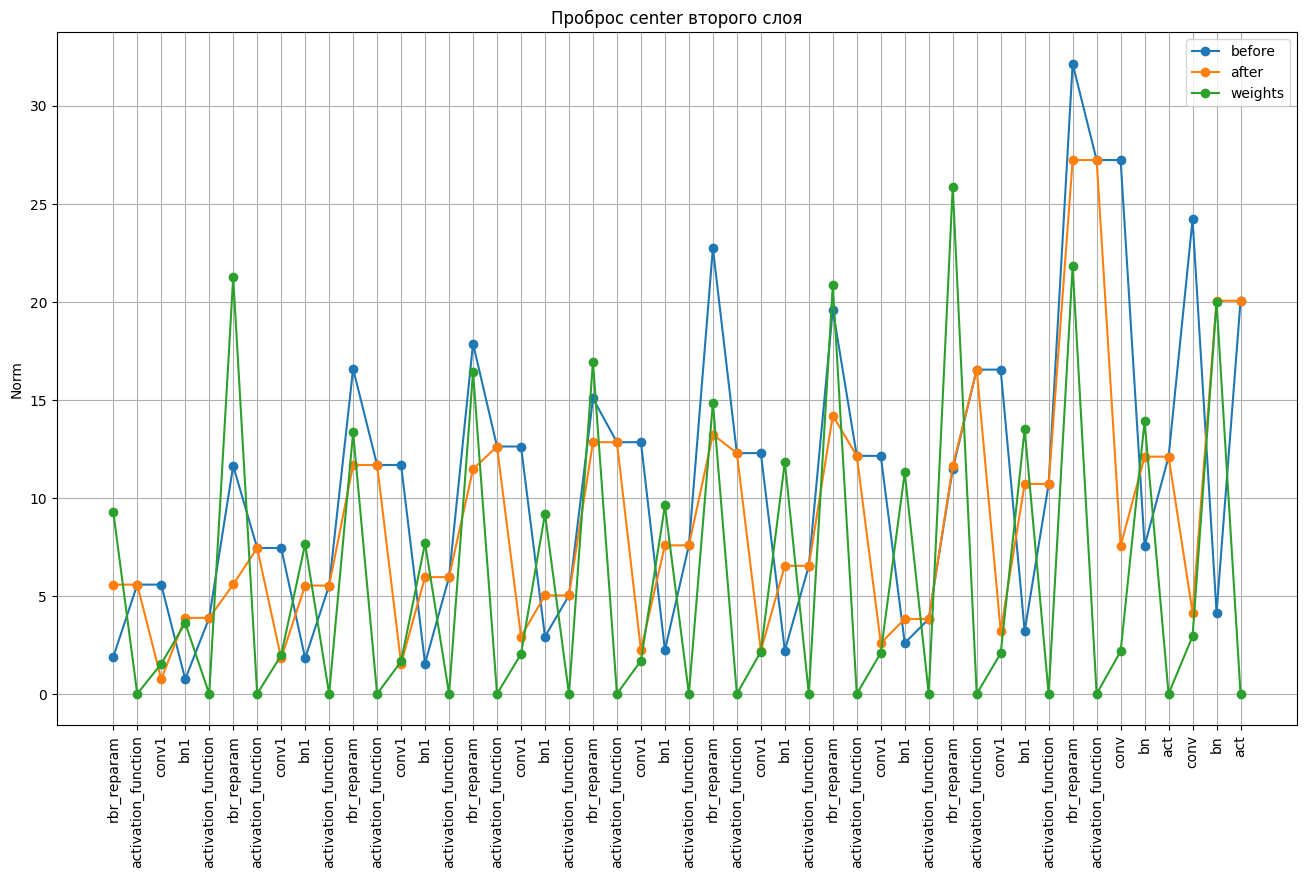

In [28]:
fig, ax = plt.subplots(figsize=(16, 9))

x = np.arange(0, len(layers) - 6)
a = [torch.norm(layers[i][2].detach().cpu()) for i in range(6, len(layers))]
b = [torch.norm(layers[i][3].detach().cpu()) for i in range(6, len(layers))]
d = [torch.norm(layers[i][-1].detach().cpu()) for i in range(6, len(layers))]
ax.plot(x, a, label='before', marker='o')
ax.plot(x, b, label='after', marker='o')
ax.plot(x, d, label='weights', marker='o')
# plt.xlabel('Номер слоя')
plt.ylabel('Norm')
plt.xticks(x, [layers[i + 6][0].split('.')[-1] for i in x], rotation=90)
plt.grid()
plt.legend()
plt.title(f'Проброс {signal_} второго слоя')

# draw_simple_dependency_graph(
#     ax,
#     y_level=0,
#     node_count=(len(layers) - 4),
#     edges=[(0, 4), (3, 4), (6, 10), (9, 10)],
#     x=x
# )

# plt.savefig('42.1. проброс весов с reparam.png')
plt.show()

In [ ]:
# check relu

a1 = [layers[i][2].detach().cpu() for i in range(6, len(layers))]
torch.all(a1[1] >= 0)

tensor(True)

## Нормы

In [74]:
# torch.Size([1, 96, 3, 3])   torch.Size([1, 192, 2, 2])   torch.Size([1, 384, 1, 1])   - cent x0-x2
# torch.Size([1, 96, 80, 80]) torch.Size([1, 192, 40, 40]) torch.Size([1, 384, 20, 20]) - orig x0-x2

# torch.Size([1, 96, 4, 4])   torch.Size([1, 192, 2, 2])   torch.Size([1, 384, 1, 1])   - cent after pad hook x0-x2

# torch.Size([1, 192, 1, 1]) - cent x13
# torch.Size([1, 576, 1, 1]) - cent x3

# torch.Size([1, 192, 20, 20]) - orig x13
# torch.Size([1, 576, 20, 20]) - orig x3


# cent mid_out
# torch.Size([1, 192, 1, 1])
# torch.Size([1, 192, 3, 3])
# torch.Size([1, 192, 3, 3])
# torch.Size([1, 192, 3, 3])

# orig mid_out
# torch.Size([1, 192, 20, 20])
# torch.Size([1, 192, 20, 20])
# torch.Size([1, 192, 20, 20])
# torch.Size([1, 192, 20, 20])
# torch.Size([1, 96, 40, 40])
# torch.Size([1, 96, 40, 40])
# torch.Size([1, 96, 40, 40])
# torch.Size([1, 96, 40, 40])
# torch.Size([1, 32, 80, 80])
# torch.Size([1, 32, 80, 80])
# torch.Size([1, 32, 80, 80])
# torch.Size([1, 32, 80, 80])
# torch.Size([1, 64, 40, 40])
# torch.Size([1, 64, 40, 40])
# torch.Size([1, 64, 40, 40])
# torch.Size([1, 64, 40, 40])
# torch.Size([1, 128, 20, 20])
# torch.Size([1, 128, 20, 20])
# torch.Size([1, 128, 20, 20])
# torch.Size([1, 128, 20, 20])

In [18]:
len(convs)

47

In [19]:
before_conv = np.array([convs[i][2].detach().cpu() for i in range(len(bns))], dtype=object)
after_conv = np.array([convs[i][3].detach().cpu() for i in range(len(bns))], dtype=object)

after_center = np.array([bns[i][2].detach().cpu()
                       - bns[i][1].running_mean.view(-1, 1, 1).detach().cpu() for i in range(len(bns))], dtype=object)
weights = np.array([convs[i][-1].detach().cpu() for i in range(len(bns))], dtype=object)
names = np.array([convs[i][0] for i in range(len(bns))], dtype=object)

# after_norm = np.array([after_center[i] /
#                        torch.sqrt(bns[i][1].running_var.view(-1, 1, 1).detach().cpu()
#                                 + bns[i][1].eps).detach().cpu() for i in range(len(bns))], dtype=object)

data = [(i + 1, before_conv[i].shape, after_conv[i].shape, after_center[i].shape, weights[i].shape, names[i]) for i in range(len(bns))]
print(tabulate(data, headers=["Layer", "before_conv size", "after_conv size", "after_center size", "weights", 'name'], tablefmt="grid"))

+---------+----------------------------+----------------------------+----------------------------+------------------------------+------------------------------------------------+
|   Layer | before_conv size           | after_conv size            | after_center size          | weights                      | name                                           |
+=========+============================+============================+============================+==============================+================================================+
|       1 | torch.Size([12, 320, 320]) | torch.Size([24, 320, 320]) | torch.Size([24, 320, 320]) | torch.Size([24, 12, 3, 3])   | backbone.block_list.0.conv.conv                |
+---------+----------------------------+----------------------------+----------------------------+------------------------------+------------------------------------------------+
|       2 | torch.Size([24, 320, 320]) | torch.Size([24, 320, 320]) | torch.Size([24, 320, 320]) | torch.

Text(0.5, 1.0, 'Проброс weights второго слоя')

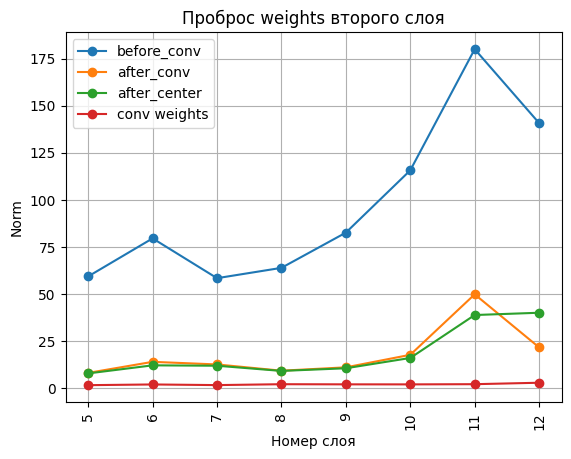

In [52]:
right_border = 12
# right_border = len(before_conv)

x = np.arange(0, right_border - 4)
a = [torch.norm(before_conv[i]) for i in range(4, right_border)]
b = [torch.norm(after_conv[i]) for i in range(4, right_border)]
c = [torch.norm(after_center[i]) for i in range(4, right_border)]
d = [torch.norm(weights[i]) for i in range(4, right_border)]
plt.plot(x, a, label='before_conv', marker='o')
plt.plot(x, b, label='after_conv', marker='o')
plt.plot(x, c, label='after_center', marker='o')
plt.plot(x, d, label='conv weights', marker='o')
plt.xlabel('Номер слоя')
plt.ylabel('Norm')
plt.xticks(x, [str(i + 5) for i in x], rotation=90)
plt.grid()
plt.legend()
plt.title(f'Проброс {signal_} второго слоя')
# if signal_ == 'weights':
#     plt.savefig('42. проброс весов.png')
# else:
#     plt.savefig('41. проброс центра.png')

In [ ]:
import plotly.colors as pc
import plotly.graph_objects as go

max_len = 10

all_data = []

for i in enumerated_layers.keys():
    if i % 2 == 1: continue
    if i == 8: continue

    bns, convs = register_conv_bn_hooks(model)

    f, s = enumerated_layers[i]

    # Подготовим центр
    signal = model.backbone.block_list[f].block_list[s].conv1.bn1.running_mean.view(1, -1, 1, 1) if signal_ == 'center'\
        else torch.Tensor(model.backbone.block_list[f].block_list[s].conv1.conv1.weight.cpu()).to(torch.device('cuda'))

    # Внедряем в модель
    layers = []
    inject_center_and_patch_model(
        model,
        layer_name_to_replace=f'backbone.block_list.{f}.block_list.{s}.conv1.bn1',  # имя нужного слоя
        new_signal=signal
    )
    
    # Прогоняем forward
    try:
        origin_image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        image, origin_shape = infer_engine.preprocess(origin_image)
        output = model(image)
    except Exception as e:
        print(f"Ожидаемая ошибка при прогоне модели: {e}")
    
    # Собираем результаты
    before_conv = np.array([convs[i][2].detach().cpu() for i in range(len(bns))], dtype=object)
    after_conv = np.array([convs[i][3].detach().cpu() for i in range(len(bns))], dtype=object)
    after_center = np.array([bns[i][2].detach().cpu() - 
                            bns[i][1].running_mean.view(-1, 1, 1).detach().cpu() 
                            for i in range(len(bns))], dtype=object)
    weights = np.array([convs[i][-1].detach().cpu() for i in range(len(bns))], dtype=object)

    right_border = 12
    
    a = [torch.norm(before_conv[j]) for j in range(i, right_border)]
    b = [torch.norm(after_conv[j]) for j in range(i, right_border)]
    c = [torch.norm(after_center[j]) for j in range(i, right_border)]

    if i == 2:
        d = [torch.norm(weights[j]) for j in range(i, right_border)]
    else :
        d = None

    all_data.append({
        "layer": i,
        "before_conv": a,
        "after_conv": b,
        "after_center": c,
        "conv_weights": d
    })


# ==== Палитры для разных типов метрик =====
def get_adjusted_colorscale(name, n_colors, min_val=0.3, max_val=1.0):
    return pc.sample_colorscale(name, np.linspace(min_val, max_val, n_colors))

palette_before = get_adjusted_colorscale('Blues', len(all_data))
palette_after = get_adjusted_colorscale('Reds', len(all_data))
palette_center = get_adjusted_colorscale('Greens', len(all_data))
palette_weights = get_adjusted_colorscale('Purples', 1)  # веса только у первого слоя

# ===== Длина общей оси X и выравнивание вправо =====
def series_lengths(d):
    lens = [len(d["before_conv"]), len(d["after_conv"]), len(d["after_center"])]
    if d.get("conv_weights") is not None:
        lens.append(len(d["conv_weights"]))
    return max(lens)

axis_len = max(series_lengths(d) for d in all_data)

# ===== Построение =====
fig = go.Figure()

for idx, data in enumerate(all_data):
    layer = data["layer"]

    # before_conv
    y = data["before_conv"]
    x = list(range(axis_len - len(y), axis_len))  # прижимаем к правому краю
    fig.add_trace(go.Scatter(
        x=x, y=y, mode='lines+markers',
        name=f"before_conv: layer {layer}",
        line=dict(color=palette_before[idx]),
        legendgroup='before_conv',
        hovertemplate=f'before_conv (layer {layer})<br>x=%{{x}}<br>y=%{{y}}'
    ))

    # after_conv
    y = data["after_conv"]
    x = list(range(axis_len - len(y), axis_len))
    fig.add_trace(go.Scatter(
        x=x, y=y, mode='lines+markers',
        name=f"after_conv: layer {layer}",
        line=dict(color=palette_after[idx]),
        legendgroup='after_conv',
        hovertemplate=f'after_conv (layer {layer})<br>x=%{{x}}<br>y=%{{y}}'
    ))

    # after_center
    y = data["after_center"]
    x = list(range(axis_len - len(y), axis_len))
    fig.add_trace(go.Scatter(
        x=x, y=y, mode='lines+markers',
        name=f"after_center: layer {layer}",
        line=dict(color=palette_center[idx]),
        legendgroup='after_center',
        hovertemplate=f'after_center (layer {layer})<br>x=%{{x}}<br>y=%{{y}}'
    ))

    # conv_weights — только для первого слоя (если сохранены)
    if data.get("conv_weights") is not None:
        y = data["conv_weights"]
        x = list(range(axis_len - len(y), axis_len))
        fig.add_trace(go.Scatter(
            x=x, y=y, mode='lines+markers',
            name=f"conv_weights: layer {layer}",
            line=dict(color=palette_weights[0]),
            legendgroup='conv_weights',
            hovertemplate=f'conv_weights (layer {layer})<br>x=%{{x}}<br>y=%{{y}}'
        ))

# ===== Оформление =====
title_text = f"Проброс {signal_} для нескольких слоёв"
fig.update_layout(
    title=title_text,
    hovermode='x',
    legend=dict(
        title='Метрики и слои',
        itemclick='toggleothers',
        itemdoubleclick='toggle'
    ),
    xaxis=dict(title='Номер шага', tickangle=90),
    yaxis=dict(title='Norm'),
    template='plotly_white'
)

# ===== Кастомные xticks =====
x = np.arange(0, right_border - 2)
xticks_labels = [str(j + 2 + 1) for j in x]
if xticks_labels:
    fig.update_xaxes(
        tickmode='array',
        tickvals=list(range(axis_len)),
        ticktext=xticks_labels
    )

fig.show()

# fig.write_html("45. Проброс весов нескольких слоёв.html")

returned new signal on  BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
changed padding: torch.Size([24, 24, 3, 3]) Conv2d(24, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
ConvKXBN(
  (conv1): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
)
RepConv(
  (nonlinearity): Identity()
  (rbr_reparam): Conv2d(24, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
)
torch.Size([24, 64, 1, 1])
torch.Size([1, 24, 320, 320])
changed padding: torch.Size([24, 24, 3, 3]) Conv2d(24, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
ConvKXBN(
  (conv1): Conv2d(64, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
)
RepConv(
  (nonlinearity): Identity()
  (rbr_reparam): Conv2d(24, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
torch.Size([24, 64, 1,

In [44]:
from tabulate import tabulate

data = [(name, module, input.size(), output.size()) for name, module, input, output in bns]
print(tabulate(data, headers=["Название", "Слой", "Размер входа", "Размер выхода"], tablefmt="grid"))

+----------------------------------------------+-----------------------------------------------------------------------------------+----------------------------+----------------------------+
| Название                                     | Слой                                                                              | Размер входа               | Размер выхода              |
+==============================================+===================================================================================+============================+============================+
| backbone.block_list.0.conv.bn                | BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)  | torch.Size([24, 320, 320]) | torch.Size([24, 320, 320]) |
+----------------------------------------------+-----------------------------------------------------------------------------------+----------------------------+----------------------------+
| backbone.block_list.1.block_list.0.conv1.bn

# Графики углов

In [ ]:
import torch.nn.functional as F

def pairwise_cosine_similarity(x1, x2):
    x1 = F.normalize(x1, dim=0)
    x2 = F.normalize(x2, dim=0)
    return x1.T @ x2

In [ ]:
center_csm = []
for k in tqdm(range(2, len(before_conv))):
    cent = bns[k][1].running_mean.view(-1, 1, 1).detach().cpu()
    matr = after_norm[k].flatten(1, 2).detach()
    center_csm.append(pairwise_cosine_similarity(cent, matr).squeeze().mean())

  0%|          | 0/45 [00:00<?, ?it/s]

In [ ]:
oneclass = False

if oneclass == False:
    inside = []
    outside = []
    back = []
    inside_all = []
    outside_all = []
    back_all = []
else:
    inside1class = []
    outside1class = []
    back1class = []

# q = torch.Tensor([0.05, 0.25, 0.5, 0.75, 0.95])

for k in tqdm(range(1, len(before_conv))):
    positions, class_names = get_positions_of_classes_on_flattened_image_for_collage(idx, after_norm[k].size()[1], "gray_")

    # if before_conv[k].size()[1] != after_conv[k].size()[1]:
    #     # a = after_conv[k].copy()
    #     u = torch.nn.Upsample(scale_factor=2, mode='bilinear')
    #     a = u(after_conv[k].unsqueeze(0)).squeeze()
    #     matr1 = a.flatten(1, 2).detach()
    # else:
    #     matr1 = after_conv[k].flatten(1, 2).detach()
    # matr2 = before_conv[k].flatten(1, 2).detach()

    # matr1 = after_center[k].flatten(1, 2).detach()
    # matr2 = after_conv[k].flatten(1, 2).detach()
    cent = bns[k][1].running_mean.view(-1, 1, 1).detach().cpu()
    matr = after_norm[k].flatten(1, 2).detach()

    # csm = pairwise_cosine_similarity(matr1, matr1) - pairwise_cosine_similarity(matr2, matr2) # torch.tensor
    csm = pairwise_cosine_similarity(matr, matr) # torch.tensor
    n = len(positions)

    mean_angle_change_w_others_list = []
    angle_change_w_self_list = []
    angle_change_w_back_list = []

    m = (1, 2) if oneclass else ([n - 1])
    # for i in range(n - 1):
    # Для 1 класса
    # for i in range(1):
    for i in range(*m):

        mean_angle_change_w_others = 0
        angle_change_w_self = 0
        angle_change_w_back = 0
        # mean_angle_change_w_others_list_inner = []
        # angle_change_w_self_list_inner = []
        # angle_change_w_back_list_inner = []
        
        for j in range(n):
            pos_i = torch.tensor(positions[i + 1], device=csm.device)
            pos_j = torch.tensor(positions[j + 1], device=csm.device)
            pair_matrix = torch.meshgrid(pos_i, pos_j)
            submatrix = csm[pair_matrix[0], pair_matrix[1]]

            mean = submatrix.mean()
            # quantiles = torch.quantile(submatrix.flatten(), q)
            
            if i == j:
                angle_change_w_self_list.append(mean)
                # angle_change_w_self_list_inner.append(quantiles)
                # angle_change_w_self = mean
            elif j == (n - 1):
                angle_change_w_back_list.append(mean)
                # angle_change_w_back_list_inner.append(quantiles)
                # angle_change_w_back = mean
            else:
                mean_angle_change_w_others += mean
                # mean_angle_change_w_others_list_inner.append(quantiles)
        
        mean_angle_change_w_others /= (n - 2)
        mean_angle_change_w_others_list.append(mean_angle_change_w_others)
        # angle_change_w_self_list.append(torch.stack(angle_change_w_self_list_inner).mean(dim=0))
        # angle_change_w_back_list.append(torch.stack(angle_change_w_back_list_inner).mean(dim=0))
        # mean_angle_change_w_others_list.append(torch.stack(mean_angle_change_w_others_list_inner).mean(dim=0))


    if oneclass == False:
        inside.append(torch.tensor(angle_change_w_self_list).mean())
        outside.append(torch.tensor(mean_angle_change_w_others_list).mean())
        back.append(torch.tensor(angle_change_w_back_list).mean())
        inside_all.append(torch.tensor(angle_change_w_self_list))
        outside_all.append(torch.tensor(mean_angle_change_w_others_list))
        back_all.append(torch.tensor(angle_change_w_back_list))
    else:
        inside1class.append(torch.tensor(angle_change_w_self_list).mean())
        outside1class.append(torch.tensor(mean_angle_change_w_others_list).mean())
        back1class.append(torch.tensor(angle_change_w_back_list).mean())
    
    # inside.append(torch.stack(angle_change_w_self_list).mean(dim=0))
    # outside.append(torch.stack(mean_angle_change_w_others_list).mean(dim=0))
    # back.append(torch.stack(angle_change_w_back_list).mean(dim=0))


  0%|          | 0/45 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=1.19s)
creating index...
index created!
loading annotations into memory...
Done (t=2.01s)
creating index...
index created!
loading annotations into memory...
Done (t=1.88s)
creating index...
index created!
loading annotations into memory...
Done (t=0.88s)
creating index...
index created!
loading annotations into memory...
Done (t=0.73s)
creating index...
index created!
loading annotations into memory...
Done (t=0.81s)
creating index...
index created!
loading annotations into memory...
Done (t=0.73s)
creating index...
index created!
loading annotations into memory...
Done (t=0.77s)
creating index...
index created!
loading annotations into memory...
Done (t=0.79s)
creating index...
index created!
loading annotations into memory...
Done (t=0.70s)
creating index...
index created!
loading annotations into memory...
Done (t=0.74s)
creating index...
index created!
loading annotations into memory...
Done (t=0.86s)
creating index...
index created!
load

In [ ]:
# inside1class

In [ ]:
# inside, outside, back
# inside

In [ ]:
# [inside1class[i] - inside[i].mean() for i in range(len(inside))]

In [ ]:
# def scale(X, mini, maxi, range_=(-1, 1)):
#     min_, max_ = range_
#     X = np.array(X)
#     X_std = (X - mini) / (maxi - mini)
#     X_scaled = X_std * (max_ - min_) + min_
#     return X_scaled

# a_min = min(np.min(inside), np.min(outside), np.min(back))
# a_max = max(np.max(inside), np.max(outside), np.max(back))
# inside_scaled = scale(inside, a_min, a_max)
# outside_scaled = scale(outside, a_min, a_max)
# back_scaled = scale(back, a_min, a_max)


In [ ]:
inside_np = torch.stack(inside_all).cpu().numpy()  # (95, 5)
outside_np = torch.stack(outside_all).cpu().numpy()  # (95, 5)
back_np = torch.stack(back_all).cpu().numpy()  # (95, 5)

In [ ]:
bns_fwd_names = [name for name, _, _, _ in bns]
len(bns_fwd_names)

47

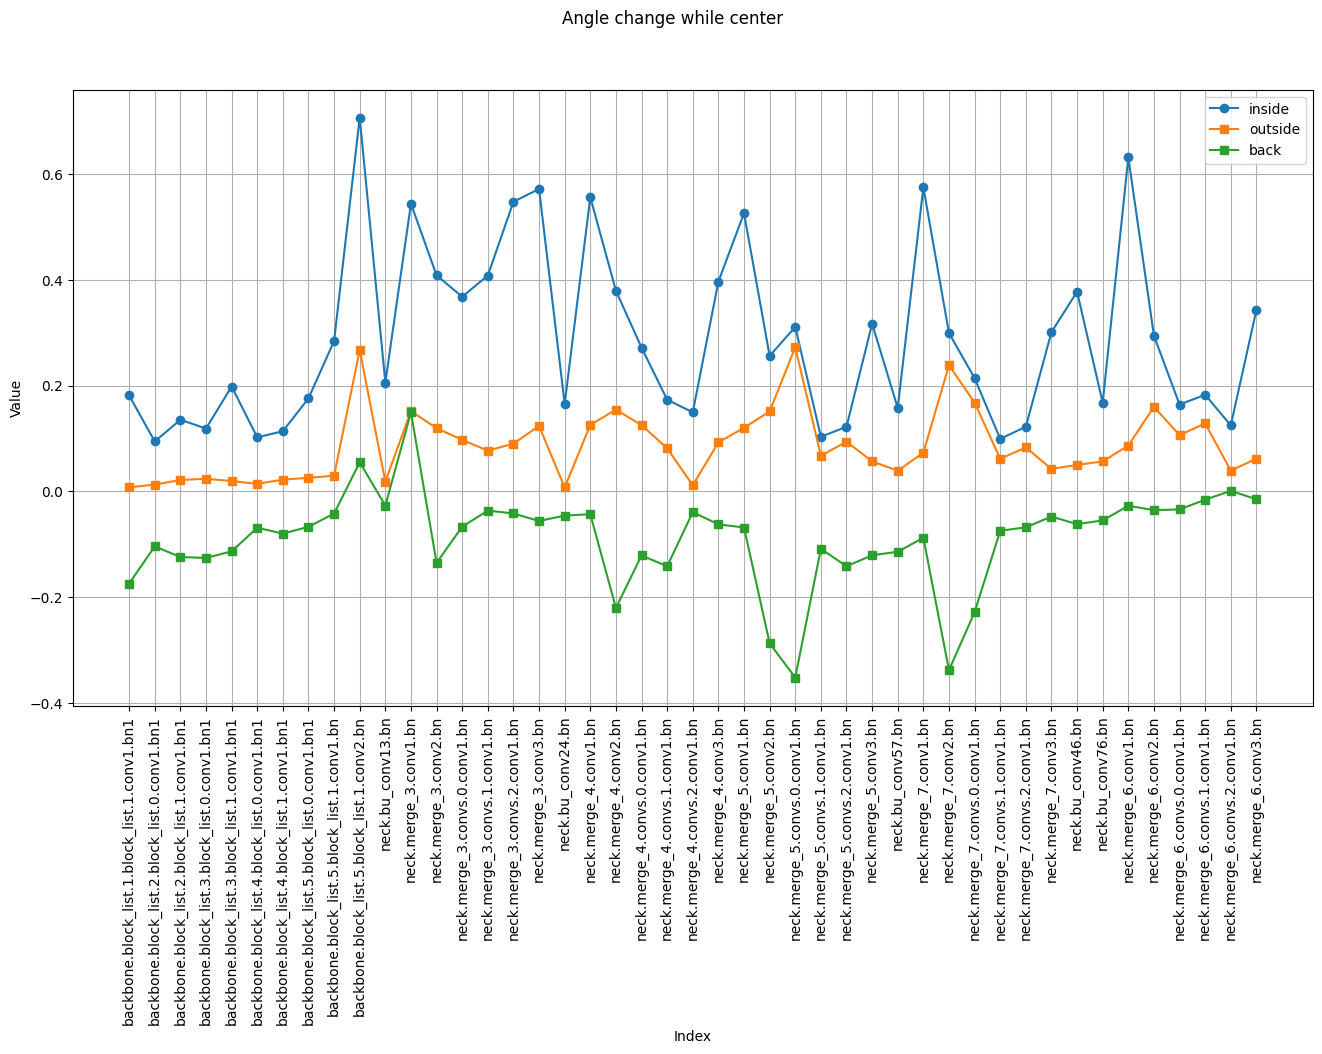

In [ ]:
# x = np.arange(3, len(before_conv) + 1)

# plt.figure(figsize=(16, 8))

# # _np[:, 2]
# plt.plot(x, inside, marker='o', label='inside', linestyle='-')
# plt.plot(x, outside,  marker='s', label='outside', linestyle='-')
# plt.plot(x, back,  marker='s', label='back', linestyle='-')

# # plt.xticks(x, [str(i) for i in x], rotation=90)
# plt.xticks(x, [bns_fwd_names[i - 1] for i in x], rotation=90)

# # plt.axvline(x=30.5, color='black', linestyle='--')

# # plt.text(10, 0.8, 'Backbone', ha='right', fontsize=12)
# # plt.text(40, 0.8, 'Neck', ha='left', fontsize=12)

# plt.xlabel("Index")
# plt.ylabel("Value")
# plt.legend()
# plt.grid(True)
# plt.suptitle("Angle change while center")
# # if savefig: plt.savefig("18.10. Изменение углов по всей модели при свёртке.png")
# plt.show();


In [ ]:
import re
from collections import defaultdict, deque

def clean_label(label):
    # # Удаляем всё после скобок (если есть)
    # label = re.sub(r'\s*\(.*?\)', '', label)
    # return label.strip()
    return label.split()[0].strip('"')

def parse_graphviz_file(file_path):
    edges = []  # Список ребер (id_from, id_to)
    labels = {}  # id -> label

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            edge_match = re.match(r'(\d+)\s*->\s*(\d+)', line)
            if edge_match:
                src, dst = edge_match.groups()
                edges.append((src, dst))
                continue

            label_match = re.match(r'(\d+)\s*\[label=(.+?)\]', line)
            if label_match:
                node_id, raw_label = label_match.groups()
                clean = clean_label(raw_label)
                labels[node_id] = clean

    return edges, labels

def build_graph(edges):
    forward = defaultdict(list)
    backward = defaultdict(list)
    for src, dst in edges:
        forward[src].append(dst)
        backward[dst].append(src)
    return forward, backward

def find_batchnorm_names(forward, backward, labels):
    batchnorm_map = {}

    for node_id, label in labels.items():
        if label != 'NativeBatchNormBackward0':
            continue

        # Ищем соседей назад (в AccumulateGrad)
        acc_nodes = backward.get(node_id, [])
        for acc in acc_nodes:
            if labels.get(acc) != 'AccumulateGrad':
                continue

            # Назад от AccumulateGrad, ищем узел с названием
            for candidate in backward.get(acc, []):
                name = labels.get(candidate)
                if name and 'bn' in name:
                    batchnorm_map[node_id] = '.'.join(name.split('.')[:-1])
                    break

            if node_id in batchnorm_map:
                break  # Достаточно одного имени

    return batchnorm_map

def bfs_batchnorm_connections(start_nodes, forward, labels, batchnorm_map):
    result = defaultdict(list)
    id_to_name = {v: k for k, v in batchnorm_map.items()}

    for src_id, src_name in batchnorm_map.items():
        visited = set()
        queue = deque([src_id])

        while queue:
            current = queue.popleft()
            for neighbor in forward.get(current, []):
                if neighbor in visited:
                    continue
                visited.add(neighbor)

                if neighbor in batchnorm_map and neighbor != src_id:
                    result[src_name].append(batchnorm_map[neighbor])
                else:
                    queue.append(neighbor)

    return result

# --- Пример использования ---
file_path = './architecture_all_deploy.txt'
edges, labels = parse_graphviz_file(file_path)
forward, backward = build_graph(edges)
batchnorm_map = find_batchnorm_names(forward, backward, labels)
connections = bfs_batchnorm_connections(batchnorm_map, forward, labels, batchnorm_map)
connections['neck.merge_6.conv3.bn'] = []

# for bn_label, reachable_bn_labels in connections.items():
#     print(f"{bn_label} -> {reachable_bn_labels}")


In [ ]:
def draw_bn_dependency_graph_inline(ax, y_values, bns_fwd_names, bn_connections):
    x_coords = {name: i for i, name in enumerate(bns_fwd_names)}
    y_min = min(y_values)
    base_y = y_min - 0.5

    allowed = set(bns_fwd_names)
    edges = [
        (src, dst) for src, dsts in bn_connections.items() if src in allowed
        for dst in dsts if dst in allowed
    ]
    pos = {name: (x_coords[name], base_y) for name in bns_fwd_names}

    for src, dst in edges:
        x1, y1 = pos[src]
        x2, y2 = pos[dst]
        dx = abs(x2 - x1)

        if dx == 1:
            style = "arc3,rad=0.01"
            width = 0.5
            color = "gray"
        else:
            style = f"arc3,rad={0.3 if dx < 5 else 0.5}"
            width = 1.0
            color = "darkblue"

        ax.annotate(
            "", xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(arrowstyle="-|>", lw=width, color=color, connectionstyle=style)
        )

    highlight_nodes = {
        "neck.merge_7.conv3.bn",
        "neck.merge_6.conv3.bn",
        "neck.merge_5.conv3.bn",
    }

    for name, (x, y) in pos.items():
        from matplotlib.patches import Ellipse
        ax.plot(x, y, 'o', color='black', markersize=4)
        # ax.text(x, y - 0.2, name, fontsize=7, rotation=90, ha='center', va='top')

        if name in highlight_nodes:
            # Добавляем обводку вокруг узла
            ax.add_patch(Ellipse((x, y), 0.7, 0.07, fill=False, color='red'))

    # ax.set_ylim(base_y - 0.5, max(y_values) + 0.5)


In [ ]:
def draw_bn_dependency_graph_inline_2(ax, y_values, bns_fwd_names, bn_connections, base_y=-0.5):
    x_coords = {name: i for i, name in enumerate(bns_fwd_names)}
    # base_y = -0.5  # Гарантированно в пределах ylim(-1, 1)

    allowed = set(bns_fwd_names)
    edges = [
        (src, dst) for src, dsts in bn_connections.items() if src in allowed
        for dst in dsts if dst in allowed
    ]
    pos = {name: (x_coords[name], base_y) for name in bns_fwd_names}

    for src, dst in edges:
        x1, y1 = pos[src]
        x2, y2 = pos[dst]
        dx = abs(x2 - x1)

        if dx == 1:
            style = "arc3,rad=0.01"
            width = 0.5
            color = "gray"
        else:
            style = f"arc3,rad={0.3 if dx < 5 else 0.5}"
            width = 1.0
            color = "darkblue"

        ax.annotate(
            "", xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(arrowstyle="-|>", lw=width, color=color, connectionstyle=style)
        )

    highlight_nodes = {
        "neck.merge_7.conv3.bn",
        "neck.merge_6.conv3.bn",
        "neck.merge_5.conv3.bn",
    }

    for name, (x, y) in pos.items():
        from matplotlib.patches import Ellipse
        ax.plot(x, y, 'o', color='black', markersize=4)

        if name in highlight_nodes:
            ax.add_patch(Ellipse((x, y), 0.7, 0.07, fill=False, color='red'))

    # Убираем set_ylim – он есть снаружи


In [ ]:
inout = [inside[i] - outside[i] for i in range(len(inside))]
inback = [inside[i] - back[i] for i in range(len(inside))]
outback = [outside[i] - back[i] for i in range(len(inside))]

In [ ]:
indiff = [inside1class[i] - inside[i].mean() for i in range(len(inside))]
outdiff = [outside1class[i] - outside[i].mean() for i in range(len(inside))]
backdiff = [back1class[i] - back[i].mean() for i in range(len(inside))]

In [ ]:
# backdiff

In [ ]:
len(inside)

45

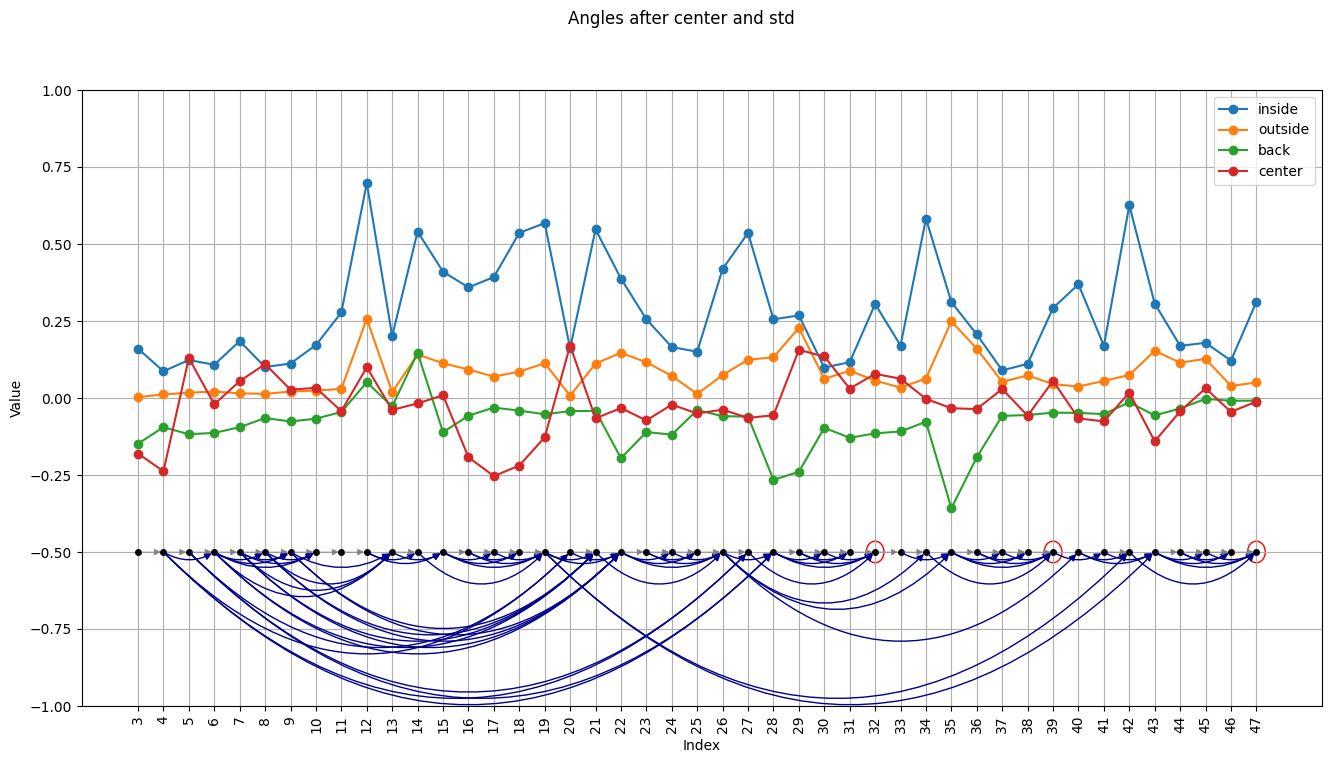

In [ ]:
# x = np.arange(3, len(before_conv) + 1)
x = np.arange(0, len(before_conv) - 2)

# plt.figure(figsize=(16, 8))
fig, ax = plt.subplots(figsize=(16, 8))

# _np[:, 2]
ax.plot(x, inside, marker='o', label='inside', linestyle='-')
ax.plot(x, outside, marker='o', label='outside', linestyle='-')
ax.plot(x, back, marker='o', label='back', linestyle='-')

ax.plot(x, center_csm, marker='o', label='center', linestyle='-')


# ax.plot(x, indiff, marker='o', label='inside1class - inside', linestyle='-')
# ax.plot(x, outdiff, marker='s', label='outside1class - outside', linestyle='-')
# ax.plot(x, backdiff, marker='s', label='back1class - back', linestyle='-')
# for i in range(n - 1):
#     ax.plot(x, inside_np[:, i], marker='o', label='inside', linestyle='-')
# ax.plot(x, outside, marker='s', label='outside', linestyle='-')
# ax.plot(x, back, marker='s', label='back', linestyle='-')

# ax.plot(x, inout, marker='o', label='inside - outside', linestyle='-')
# ax.plot(x,  outback,  marker='s', label='outside - back', linestyle='-')
# ax.plot(x, inback,  marker='s', label='inside - back', linestyle='-')

# draw_bn_dependency_graph_inline(ax, back, bns_fwd_names[2:], connections)
draw_bn_dependency_graph_inline_2(ax, back, bns_fwd_names[2:], connections, -0.5)
# plt.tight_layout()
# plt.show()
plt.xticks(x, [str(i + 3) for i in x], rotation=90)
plt.xlabel("Index")
plt.ylabel("Value")
plt.ylim(-1, 1)
# plt.ylim(-0.7, 0.7)
plt.legend()
plt.grid(True)
plt.suptitle("Angles after center and std")
if savefig: plt.savefig("31. Углы по всей модели после центрирования и нормирования.png")
plt.show();

In [ ]:
import numpy as np
import plotly.graph_objects as go
import plotly.colors as pc


# ==== Параметры ====
x = np.arange(3, 48)  # от 3 до 47 включительно
width = 1600
height = 800
ylim = [-1, 1]  # можно поменять


# ==== Цветовые палитры ====
def get_adjusted_colorscale(name, n_colors, min_val=0.3, max_val=1.0):
    return pc.sample_colorscale(name, np.linspace(min_val, max_val, n_colors))

palette_inside = get_adjusted_colorscale('Blues', 5)
palette_outside = get_adjusted_colorscale('Reds', 5)
palette_back = get_adjusted_colorscale('Greens', 5)


# ==== Построение ====
fig = go.Figure()

for i, class_name in enumerate(list(class_names.values())[:-1]):
    fig.add_trace(go.Scatter(
        x=x,
        y=inside_np[:, i] - inside,
        mode='lines+markers',
        name=f'inside: {class_name}',
        line=dict(color=palette_inside[i]),
        legendgroup='inside',
        hovertemplate=f'inside: {class_name}<br>x=%{{x}}<br>y=%{{y}}'
    ))
    fig.add_trace(go.Scatter(
        x=x,
        y=outside_np[:, i] - outside,
        mode='lines+markers',
        name=f'outside: {class_name}',
        line=dict(color=palette_outside[i]),
        legendgroup='outside',
        hovertemplate=f'outside: {class_name}<br>x=%{{x}}<br>y=%{{y}}'
    ))
    fig.add_trace(go.Scatter(
        x=x,
        y=back_np[:, i] - back,
        mode='lines+markers',
        name=f'back: {class_name}',
        line=dict(color=palette_back[i]),
        legendgroup='back',
        hovertemplate=f'back: {class_name}<br>x=%{{x}}<br>y=%{{y}}'
    ))


# ==== Оформление ====
fig.update_layout(
    title='Angles diff w/ averaged before conv',
    hovermode='x',
    legend=dict(
        title='Классы и источники',
        itemclick='toggleothers',
        itemdoubleclick='toggle'
    ),
    xaxis=dict(
        title='X',
        tickangle=90
    ),
    yaxis=dict(
        title='Значение',
        range=ylim
    ),
    width=width,
    height=height,
    template='plotly_white'
)

fig.show()


# ==== Сохранение ====
if savefig: fig.write_html("23.1. разница Изменение углов по всей модели при центрировании.html")

In [ ]:
class_names

{1: 'bear', 2: 'vase', 3: 'dog', 4: 'knife', 5: 'pizza', 6: 'background'}

In [ ]:
bns_idx_name_matching = {(i + 1): j for i, j in enumerate(bns_fwd_names)}
bns_idx_name_matching

{1: 'backbone.block_list.0.conv.bn',
 2: 'backbone.block_list.1.block_list.0.conv1.bn1',
 3: 'backbone.block_list.1.block_list.1.conv1.bn1',
 4: 'backbone.block_list.2.block_list.0.conv1.bn1',
 5: 'backbone.block_list.2.block_list.1.conv1.bn1',
 6: 'backbone.block_list.3.block_list.0.conv1.bn1',
 7: 'backbone.block_list.3.block_list.1.conv1.bn1',
 8: 'backbone.block_list.4.block_list.0.conv1.bn1',
 9: 'backbone.block_list.4.block_list.1.conv1.bn1',
 10: 'backbone.block_list.5.block_list.0.conv1.bn1',
 11: 'backbone.block_list.5.block_list.1.conv1.bn',
 12: 'backbone.block_list.5.block_list.1.conv2.bn',
 13: 'neck.bu_conv13.bn',
 14: 'neck.merge_3.conv1.bn',
 15: 'neck.merge_3.conv2.bn',
 16: 'neck.merge_3.convs.0.conv1.bn',
 17: 'neck.merge_3.convs.1.conv1.bn',
 18: 'neck.merge_3.convs.2.conv1.bn',
 19: 'neck.merge_3.conv3.bn',
 20: 'neck.bu_conv24.bn',
 21: 'neck.merge_4.conv1.bn',
 22: 'neck.merge_4.conv2.bn',
 23: 'neck.merge_4.convs.0.conv1.bn',
 24: 'neck.merge_4.convs.1.conv1.bn'

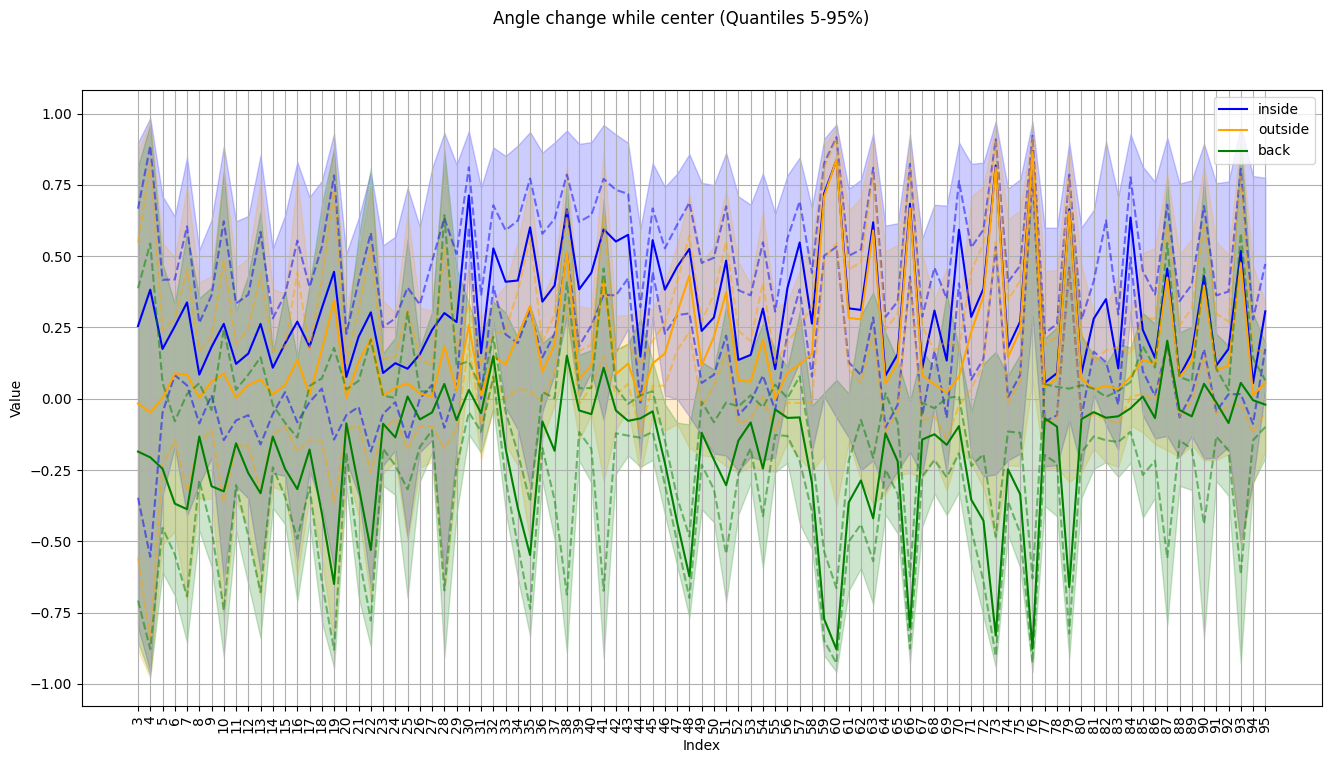

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(3, len(before_conv) + 1)

# inside = torch.stack(inside).cpu().numpy()  # (95, 5)
# outside = torch.stack(outside).cpu().numpy()
# back = torch.stack(back).cpu().numpy()

plt.figure(figsize=(16, 8))

# Функция для отрисовки трубки + линий
def plot_with_quantiles(x, quantiles, label, color):
    q05 = quantiles[:, 0]
    q25 = quantiles[:, 1]
    q50 = quantiles[:, 2]
    q75 = quantiles[:, 3]
    q95 = quantiles[:, 4]
    
    # Трубка между 5% и 95%
    plt.fill_between(x, q05, q95, alpha=0.2, color=color)
    
    # Дополнительно 25%-75%
    plt.plot(x, q25, linestyle='--', color=color, alpha=0.5)
    plt.plot(x, q75, linestyle='--', color=color, alpha=0.5)

    # Основная линия медианы
    plt.plot(x, q50, label=label, color=color)

# Рисуем все 3 серии
plot_with_quantiles(x, inside_np, label='inside', color='blue')
plot_with_quantiles(x, outside_np, label='outside', color='orange')
plot_with_quantiles(x, back_np, label='back', color='green')

plt.xticks(x, [str(i) for i in x], rotation=90)

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.suptitle("Angle change while center (Quantiles 5-95%)")
plt.show()
